# 🚀 Lab 44: Named Entity Recognition for Cybersecurity Logs

## 🎯 Objectives
1. Understand the fundamentals of Named Entity Recognition (NER) in cybersecurity.
2. Load and process cybersecurity log samples using Python.
3. Use spaCy's NER pipeline to identify organizations, dates, and products.
4. Extract and categorize IP addresses using regular expressions.
5. Detect custom threats using spaCy's Matcher.
6. Generate human-readable security reports and export data to CSV.

## 🧰 Prerequisites
* Basic Python knowledge (loops, functions, lists).
* Fundamental understanding of cybersecurity (logs, IPs, malware).
* No local setup required; this runs entirely in Google Colab.

## 🌍 Why This Lab Matters
In the real world, security analysts face millions of log lines. Manually reading them is impossible. This lab teaches you how to automate the 'highlighting' of critical information using AI and rules, allowing humans to focus on the most dangerous threats quickly.

---

## ⚙️ Task 1: Environment Setup
### 🧒 ELI10 Explanation
Before we start, we need to give our computer a "brain" that understands English and specific security terms. We are installing **spaCy**, a library that acts as a language expert, and downloading a pre-trained model that already knows how to recognize names, dates, and companies.

In [1]:
# Subtask 1.1: Install required libraries and the English spaCy model
!pip install -q spacy pandas matplotlib seaborn
!python -m spacy download en_core_web_sm

# Subtask 1.2: Verify the Installation
import spacy
print(f"✅ spaCy version {spacy.__version__} installed and model downloaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ spaCy version 3.8.14 installed and model downloaded!


## 📥 Task 2: Loading or Creating the Dataset
### 🧒 ELI10 Explanation
We need some data to work with! Since we don't have a giant server logs file yet, we will create our own list of 'suspicious' messages that look like real security alerts from companies like Microsoft, Amazon, and Google.

In [2]:
import pandas as pd
import re
import time
from collections import Counter
from IPython.display import display, HTML
from spacy import displacy
from spacy.matcher import Matcher
import matplotlib.pyplot as plt
import seaborn as sns

# Subtask 2.2: Create Sample Cybersecurity Logs
cybersecurity_logs = [
    "Failed login attempt from IP address 192.168.1.100 to Microsoft Exchange server at 2023-10-15 14:30:22",
    "Malware detected: Trojan.Win32.Agent found in file system by Symantec Endpoint Protection",
    "Suspicious network activity from 10.0.0.45 attempting to connect to known botnet C&C server 203.0.113.5",
    "DDoS attack detected from multiple IP addresses including 172.16.0.1, 172.16.0.2, and 172.16.0.3 targeting Apache web server",
    "Phishing email detected from sender@malicious-domain.com targeting employees at Acme Corporation",
    "Ransomware activity detected: WannaCry variant attempting to encrypt files on Windows workstation 192.168.10.50",
    "Firewall blocked connection attempt from 198.51.100.10 to internal database server at Oracle Corporation",
    "Intrusion detection system alert: SQL injection attempt detected on web application hosted by Amazon Web Services",
    "Unauthorized access attempt to Active Directory server from IP 203.0.113.100 at Google headquarters",
    "Vulnerability scan detected from Nessus scanner at IP address 10.10.10.5 targeting Cisco router firmware"
]

print(f"Successfully created {len(cybersecurity_logs)} sample logs.")
for i, log in enumerate(cybersecurity_logs, start=1):
    print(f"{i}. {log}")

Successfully created 10 sample logs.
1. Failed login attempt from IP address 192.168.1.100 to Microsoft Exchange server at 2023-10-15 14:30:22
2. Malware detected: Trojan.Win32.Agent found in file system by Symantec Endpoint Protection
3. Suspicious network activity from 10.0.0.45 attempting to connect to known botnet C&C server 203.0.113.5
4. DDoS attack detected from multiple IP addresses including 172.16.0.1, 172.16.0.2, and 172.16.0.3 targeting Apache web server
5. Phishing email detected from sender@malicious-domain.com targeting employees at Acme Corporation
6. Ransomware activity detected: WannaCry variant attempting to encrypt files on Windows workstation 192.168.10.50
7. Firewall blocked connection attempt from 198.51.100.10 to internal database server at Oracle Corporation
8. Intrusion detection system alert: SQL injection attempt detected on web application hosted by Amazon Web Services
9. Unauthorized access attempt to Active Directory server from IP 203.0.113.100 at Google

## 🧠 Task 3 & 4: Understanding the Data & Named Entity Extraction
### 🧒 ELI10 Explanation
Now we turn on the "AI brain." It will read every log and try to find 'Entities'. An entity is a special word like 'Google' (an Organization) or '2023-10-15' (a Date). This helps us turn messy text into a clean table.

In [3]:
# Task 3: Initialize the spaCy NLP Pipeline
nlp = spacy.load("en_core_web_sm")

# Task 4: Extract Named Entities
def extract_entities_from_logs(logs):
    all_entities = []
    for i, log in enumerate(logs):
        doc = nlp(log)
        for ent in doc.ents:
            all_entities.append({
                "log_id": i,
                "text": ent.text,
                "label": ent.label_,
                "description": spacy.explain(ent.label_),
                "start": ent.start_char,
                "end": ent.end_char,
                "log_text": log
            })
    return all_entities

entities = extract_entities_from_logs(cybersecurity_logs)
entities_df = pd.DataFrame(entities)

print("Extraction Complete. Previewing first 10 results:")
display(entities_df.head(10))

Extraction Complete. Previewing first 10 results:


,log_id,text,label,description,start,end,log_text
0,0,IP,ORG,"Companies, agencies, institutions, etc.",26,28,Failed login attempt from IP address 192.168.1...
1,0,192.168.1.100,CARDINAL,Numerals that do not fall under another type,37,50,Failed login attempt from IP address 192.168.1...
2,0,Microsoft Exchange,ORG,"Companies, agencies, institutions, etc.",54,72,Failed login attempt from IP address 192.168.1...
3,0,2023-10-15,DATE,Absolute or relative dates or periods,83,93,Failed login attempt from IP address 192.168.1...
4,1,Symantec Endpoint Protection,ORG,"Companies, agencies, institutions, etc.",61,89,Malware detected: Trojan.Win32.Agent found in ...
5,2,C&C,ORG,"Companies, agencies, institutions, etc.",81,84,Suspicious network activity from 10.0.0.45 att...
6,2,203.0.113.5,CARDINAL,Numerals that do not fall under another type,92,103,Suspicious network activity from 10.0.0.45 att...
7,3,IP,ORG,"Companies, agencies, institutions, etc.",35,37,DDoS attack detected from multiple IP addresse...
8,3,172.16.0.1,CARDINAL,Numerals that do not fall under another type,58,68,DDoS attack detected from multiple IP addresse...
9,3,172.16.0.2,DATE,Absolute or relative dates or periods,70,80,DDoS attack detected from multiple IP addresse...


## 🌐 Task 6 & 7: IP Address Extraction and Categorization
### 🧒 ELI10 Explanation
IP addresses are like phone numbers for computers. Standard AI sometimes misses them, so we use a 'Regex' (a specific search pattern) to find every IP. Then, we sort them: are they 'Private' (internal office computers) or 'Public' (the outside internet)?

In [4]:
# Task 6: Extract IP Addresses with Regex
def extract_ip_addresses(logs):
    ip_pattern = r"\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b"
    ip_list = []
    for i, log in enumerate(logs):
        matches = re.finditer(ip_pattern, log)
        for match in matches:
            ip_list.append({"log_id": i, "ip_address": match.group(), "position": match.span(), "log_text": log})
    return ip_list

# Task 7: Categorize IP Addresses
def categorize_ip_addresses(ip_list):
    categorized = {"private": [], "public": [], "special": []}
    for ip_info in ip_list:
        ip = ip_info["ip_address"]
        if re.match(r"^(10\.|172\.(1[6-9]|2[0-9]|3[0-1])\.|192\.168\.)", ip):
            categorized["private"].append({**ip_info, "category": "Internal/Private"})
        elif re.match(r"^(127\.|169\.254\.)", ip):
            categorized["special"].append({**ip_info, "category": "Special/Local"})
        else:
            categorized["public"].append({**ip_info, "category": "External/Public"})
    return categorized

ips_found = extract_ip_addresses(cybersecurity_logs)
ip_cats = categorize_ip_addresses(ips_found)

print("IP Analysis Result:")
for cat, items in ip_cats.items():
    print(f"- {cat.upper()}: {len(items)} found")

IP Analysis Result:
- PRIVATE: 7 found
- PUBLIC: 3 found
- SPECIAL: 0 found


## 📈 Task 8 & 9: Visualization / Analysis
### 🧒 ELI10 Explanation
Pictures are worth a thousand logs! We will create a colorful view where the entities are highlighted directly in the text, and then draw charts to see which types of entities appear most often.

Visualizing first 3 logs with highlights:


<IPython.core.display.HTML object>

<IPython.core.display.HTML object>

<IPython.core.display.HTML object>

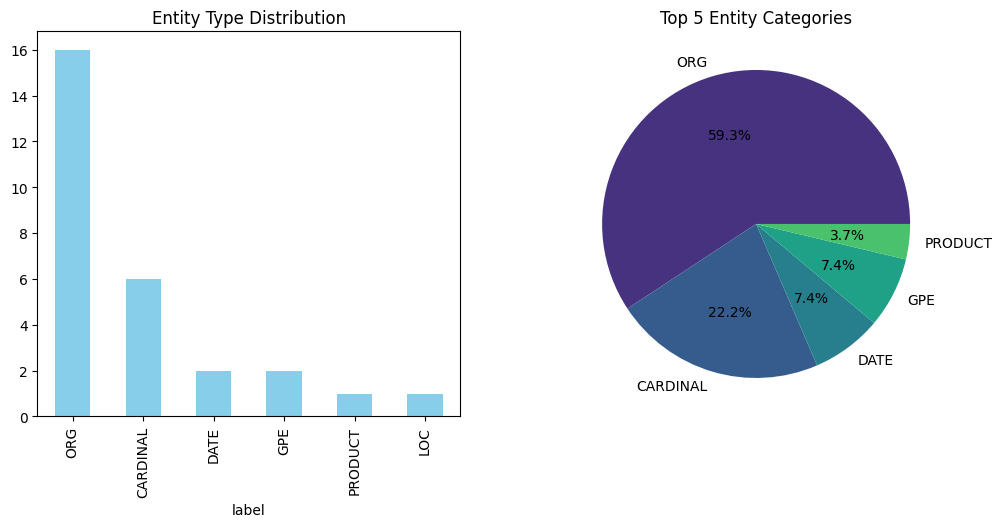

In [5]:
# Task 8: Visualize Entities in Context
print("Visualizing first 3 logs with highlights:")
for log in cybersecurity_logs[:3]:
    display(HTML(displacy.render(nlp(log), style="ent", page=False)))

# Task 9: Create Statistics Charts
def create_entity_statistics(entities):
    df = pd.DataFrame(entities)
    if df.empty: return
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    df['label'].value_counts().plot(kind='bar', color='skyblue')
    plt.title("Entity Type Distribution")

    plt.subplot(1, 2, 2)
    top_5 = df['label'].value_counts().head(5)
    plt.pie(top_5, labels=top_5.index, autopct='%1.1f%%', colors=sns.color_palette("viridis"))
    plt.title("Top 5 Entity Categories")
    plt.savefig("entity_statistics.png")
    plt.show()

create_entity_statistics(entities)

## 🛡 Task 10 & 11: Custom Cybersecurity Pattern Matching
### 🧒 ELI10 Explanation
Sometimes we want to find very specific 'bad words' like *Malware* or *DDoS*. We teach spaCy to look for these exact keywords so we never miss a threat name.

In [6]:
# Task 10: Create Custom Threat Matcher
def create_threat_patterns():
    matcher = Matcher(nlp.vocab)
    matcher.add("MALWARE", [[{"LOWER": "malware"}], [{"LOWER": "trojan"}], [{"LOWER": "wannacry"}]])
    matcher.add("ATTACK", [[{"LOWER": "ddos"}, {"LOWER": "attack"}], [{"LOWER": "phishing"}], [{"LOWER": "sql"}, {"LOWER": "injection"}]])
    matcher.add("INFRA", [[{"LOWER": "firewall"}], [{"LOWER": "server"}], [{"LOWER": "router"}]])
    return matcher

# Task 11: Apply Matcher
threat_matcher = create_threat_patterns()
custom_threats = []
for i, log in enumerate(cybersecurity_logs):
    doc = nlp(log)
    matches = threat_matcher(doc)
    for match_id, start, end in matches:
        custom_threats.append({"log_id": i, "text": doc[start:end].text, "label": nlp.vocab.strings[match_id]})

print(f"Found {len(custom_threats)} custom threat matches.")
display(pd.DataFrame(custom_threats).head())

Found 13 custom threat matches.


,log_id,text,label
0,0,server,INFRA
1,1,Malware,MALWARE
2,1,Trojan,MALWARE
3,2,server,INFRA
4,3,DDoS attack,ATTACK


## 📝 Task 13 & 14: Security Intelligence Reporting & Exporting
### 🧒 ELI10 Explanation
Finally, we summarize everything. We write a report that tells the boss what happened and save all our data into a CSV file (like an Excel sheet) so we can keep it for the future.

In [7]:
# Task 13: Generate Report
def generate_security_report(logs, entities, ips, threats):
    report = f"""============================================================
CYBERSECURITY LOG ANALYSIS REPORT
============================================================
Date: {pd.Timestamp.now()}
Logs Analyzed: {len(logs)}

--- IP SUMMARY ---
Public IPs found: {len(ips['public'])}
Private IPs found: {len(ips['private'])}

--- THREAT SUMMARY ---
Total Custom Threats: {len(threats)}

--- RECOMMENDATIONS ---
- Review external IPs for potential blocking.
- Update signatures for detected Malware families.
"""
    return report

full_report = generate_security_report(cybersecurity_logs, entities, ip_cats, custom_threats)
with open("security_analysis_report.txt", "w") as f: f.write(full_report)

# Task 14: Export CSV
pd.DataFrame(entities).to_csv("standard_entities.csv", index=False)
print("✅ Report and CSV exported successfully!")
print("\n--- REPORT PREVIEW ---")
print(full_report)

✅ Report and CSV exported successfully!

--- REPORT PREVIEW ---
CYBERSECURITY LOG ANALYSIS REPORT
Date: 2026-04-18 07:01:41.073017
Logs Analyzed: 10

--- IP SUMMARY ---
Public IPs found: 3
Private IPs found: 7

--- THREAT SUMMARY ---
Total Custom Threats: 13

--- RECOMMENDATIONS ---
- Review external IPs for potential blocking.
- Update signatures for detected Malware families.



## ✅ Verification & 🏁 Conclusion

### Verification Checklist
- [x] spaCy Model Loaded
- [x] Logs Processed
- [x] IP Addresses Categorized
- [x] CSV and TXT Files Created

### 🎓 What You Learned
You built a mini-security AI! You combined **Machine Learning** (spaCy) with **Rules** (Regex and Matcher) to turn 10 lines of messy text into organized security intelligence.

### 🌍 Real-World Importance
This is exactly how SIEM (Security Information and Event Management) tools work in big companies. They automate the boring parts of reading logs so security experts can find and stop hackers faster.